In [1]:
import sys
import os
notebook_dir = os.path.dirname(os.path.abspath(''))
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..')))

## Diabetes Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper
from joblib import Parallel, delayed

# ========================
# Charger dataset
# ========================
data = load_diabetes()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLP)
# ========================
mlp_global = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    return mlp_global.predict(X)

# ========================
# Grille fine de gammas (0.1 à 100)
# ========================
gamma1_values = np.logspace(-1, 2, 20)   # de 0.1 à 100
gamma2_values = np.logspace(-1, 1, 10)

# ========================
# Fonction pour un seul modèle
# ========================
def evaluate_gammas(g1, g2):
    model = NDTRegressorWrapper(D=X_train.shape[1], gammas=[g1, g2], epochs=500)
    model.fit(X_train, predict_fn(X_train))
    y_pred = model.predict(X_test)
    score = r2_score(predict_fn(X_test), y_pred)
    return score

# ========================
# Calcul parallèle
# ========================
scores = Parallel(n_jobs=-1)(
    delayed(evaluate_gammas)(g1, g2)
    for g2 in gamma2_values
    for g1 in gamma1_values
)

# Reshape scores pour contour plot
scores = np.array(scores).reshape(len(gamma2_values), len(gamma1_values))

# ========================
# Landscape (contour plot)
# ========================
plt.figure(figsize=(9,7))
cs = plt.contourf(gamma1_values, gamma2_values, scores, levels=50, cmap="coolwarm") # coolwarm, RdYlGn
plt.colorbar(cs, label="Fidelity to the complex model (R² score)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1")
plt.ylabel("Gamma2")
plt.title("Landscape of NDT fidelity on the Diabetes dataset")
plt.show()


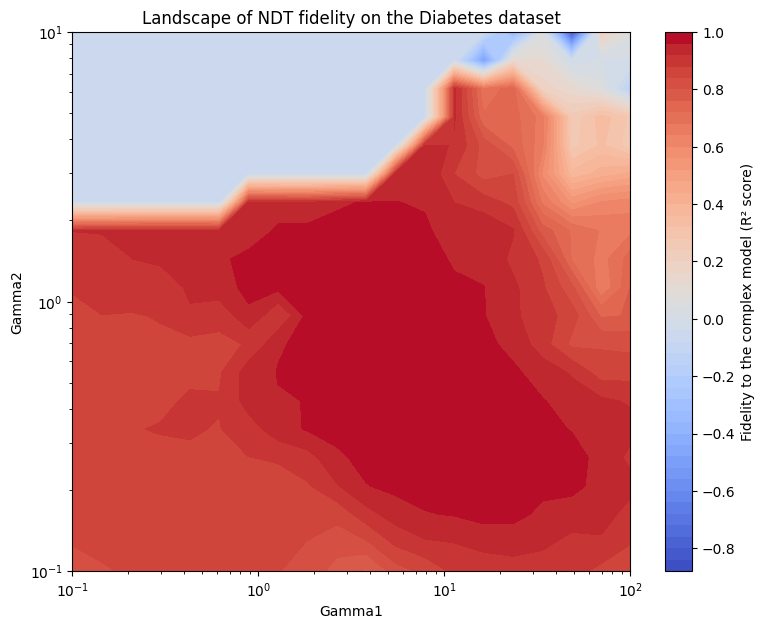

## California Housing Dataset

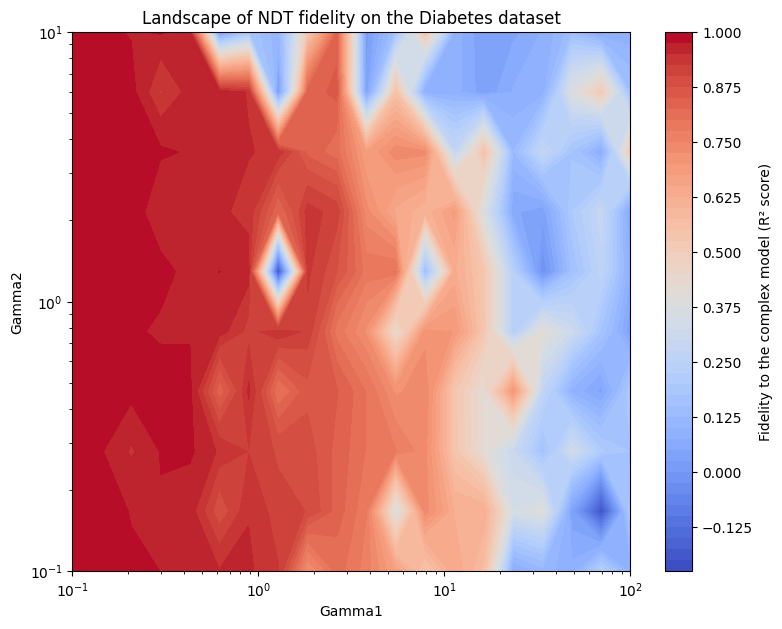

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper
from joblib import Parallel, delayed

# ========================
# Charger dataset
# ========================
data = fetch_california_housing()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLP)
# ========================
mlp_global = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    return mlp_global.predict(X)

# ========================
# Grille fine de gammas (0.1 à 100)
# ========================
gamma1_values = np.logspace(-1, 2, 20)   # de 0.1 à 100
gamma2_values = np.logspace(-1, 1, 10)

# ========================
# Fonction pour un seul modèle
# ========================
def evaluate_gammas(g1, g2):
    model = NDTRegressorWrapper(D=X_train.shape[1], gammas=[g1, g2], epochs=500)
    model.fit(X_train, predict_fn(X_train))
    y_pred = model.predict(X_test)
    score = r2_score(predict_fn(X_test), y_pred)
    return score

# ========================
# Calcul parallèle
# ========================
scores = Parallel(n_jobs=-1)(
    delayed(evaluate_gammas)(g1, g2)
    for g2 in gamma2_values
    for g1 in gamma1_values
)

# Reshape scores pour contour plot
scores = np.array(scores).reshape(len(gamma2_values), len(gamma1_values))

# ========================
# Landscape (contour plot)
# ========================
plt.figure(figsize=(9,7))
cs = plt.contourf(gamma1_values, gamma2_values, scores, levels=50, cmap="coolwarm") # coolwarm, RdYlGn
plt.colorbar(cs, label="Fidelity to the complex model (R² score)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1")
plt.ylabel("Gamma2")
plt.title("Landscape of NDT fidelity on the California Housing dataset")
plt.show()


## Iris Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPClassifier
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper
from joblib import Parallel, delayed

# ========================
# Charger dataset
# ========================
data = load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLP)
# ========================
mlp_global = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    return mlp_global.predict(X)

# ========================
# Grille fine de gammas (0.1 à 100)
# ========================
gamma1_values = np.logspace(-1, 2, 20)   # de 0.1 à 100
gamma2_values = np.logspace(-1, 1, 10)

# ========================
# Fonction pour un seul modèle
# ========================
def evaluate_gammas(g1, g2):
    model = NDTRegressorWrapper(D=X_train.shape[1], gammas=[g1, g2], epochs=500)
    model.fit(X_train, predict_fn(X_train))
    y_pred = model.predict(X_test)
    score = r2_score(predict_fn(X_test), y_pred)
    return score

# ========================
# Calcul parallèle
# ========================
scores = Parallel(n_jobs=-1)(
    delayed(evaluate_gammas)(g1, g2)
    for g2 in gamma2_values
    for g1 in gamma1_values
)

# Reshape scores pour contour plot
scores = np.array(scores).reshape(len(gamma2_values), len(gamma1_values))

# ========================
# Landscape (contour plot)
# ========================
plt.figure(figsize=(9,7))
cs = plt.contourf(gamma1_values, gamma2_values, scores, levels=50, cmap="coolwarm") # coolwarm, RdYlGn
plt.colorbar(cs, label="Fidelity to the complex model (R² score)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1")
plt.ylabel("Gamma2")
plt.title("Landscape of NDT fidelity on the Iris dataset")
plt.show()


## Breast Cancer Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPClassifier
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper
from joblib import Parallel, delayed

# ========================
# Charger dataset
# ========================
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLP)
# ========================
mlp_global = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    return mlp_global.predict(X)

# ========================
# Grille fine de gammas (0.1 à 100)
# ========================
gamma1_values = np.logspace(-1, 2, 20)   # de 0.1 à 100
gamma2_values = np.logspace(-1, 1, 10)

# ========================
# Fonction pour un seul modèle
# ========================
def evaluate_gammas(g1, g2):
    model = NDTRegressorWrapper(D=X_train.shape[1], gammas=[g1, g2], epochs=500)
    model.fit(X_train, predict_fn(X_train))
    y_pred = model.predict(X_test)
    score = r2_score(predict_fn(X_test), y_pred)
    return score

# ========================
# Calcul parallèle
# ========================
scores = Parallel(n_jobs=-1)(
    delayed(evaluate_gammas)(g1, g2)
    for g2 in gamma2_values
    for g1 in gamma1_values
)

# Reshape scores pour contour plot
scores = np.array(scores).reshape(len(gamma2_values), len(gamma1_values))

# ========================
# Landscape (contour plot)
# ========================
plt.figure(figsize=(9,7))
cs = plt.contourf(gamma1_values, gamma2_values, scores, levels=50, cmap="coolwarm") # coolwarm, RdYlGn
plt.colorbar(cs, label="Fidelity to the complex model (R² score)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1")
plt.ylabel("Gamma2")
plt.title("Landscape of NDT fidelity on the Iris dataset")
plt.show()


## Wine Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPClassifier
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper
from joblib import Parallel, delayed

# ========================
# Charger dataset
# ========================
data = load_wine()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLP)
# ========================
mlp_global = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    return mlp_global.predict(X)

# ========================
# Grille fine de gammas (0.1 à 100)
# ========================
gamma1_values = np.logspace(-1, 2, 20)   # de 0.1 à 100
gamma2_values = np.logspace(-1, 1, 10)

# ========================
# Fonction pour un seul modèle
# ========================
def evaluate_gammas(g1, g2):
    model = NDTRegressorWrapper(D=X_train.shape[1], gammas=[g1, g2], epochs=500)
    model.fit(X_train, predict_fn(X_train))
    y_pred = model.predict(X_test)
    score = r2_score(predict_fn(X_test), y_pred)
    return score

# ========================
# Calcul parallèle
# ========================
scores = Parallel(n_jobs=-1)(
    delayed(evaluate_gammas)(g1, g2)
    for g2 in gamma2_values
    for g1 in gamma1_values
)

# Reshape scores pour contour plot
scores = np.array(scores).reshape(len(gamma2_values), len(gamma1_values))

# ========================
# Landscape (contour plot)
# ========================
plt.figure(figsize=(9,7))
cs = plt.contourf(gamma1_values, gamma2_values, scores, levels=50, cmap="coolwarm") # coolwarm, RdYlGn
plt.colorbar(cs, label="Fidelity to the complex model (R² score)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1")
plt.ylabel("Gamma2")
plt.title("Landscape of NDT fidelity on the Iris dataset")
plt.show()
